# <span style = "color:beige"><center> SATELLITE IMAGE CLASSIFICATION </center></span>

***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import confusion_matrix , classification_report , accuracy_score
import glob

In [2]:
cloudy = glob.glob('data/cloudy/*.jpg')
desert = glob.glob('data/desert/*.jpg')
green_area = glob.glob('data/green_area/*.jpg')
water = glob.glob('data/water/*.jpg')

In [3]:
print(len(cloudy))
print(len(desert))
print(len(green_area))
print(len(water))

1500
1131
1500
1500


In [4]:
images = []
labels = []

for i in cloudy:
    img = plt.imread(i)
    images.append(img)
    labels.append(0)

for i in desert:
    img = plt.imread(i)
    images.append(img)
    labels.append(1)

for i in green_area:
    img = plt.imread(i)
    images.append(img)
    labels.append(2)

for i in water:
    img = plt.imread(i)
    images.append(img)
    labels.append(3)

In [5]:
images , labels = shuffle(images , labels , random_state = 12)

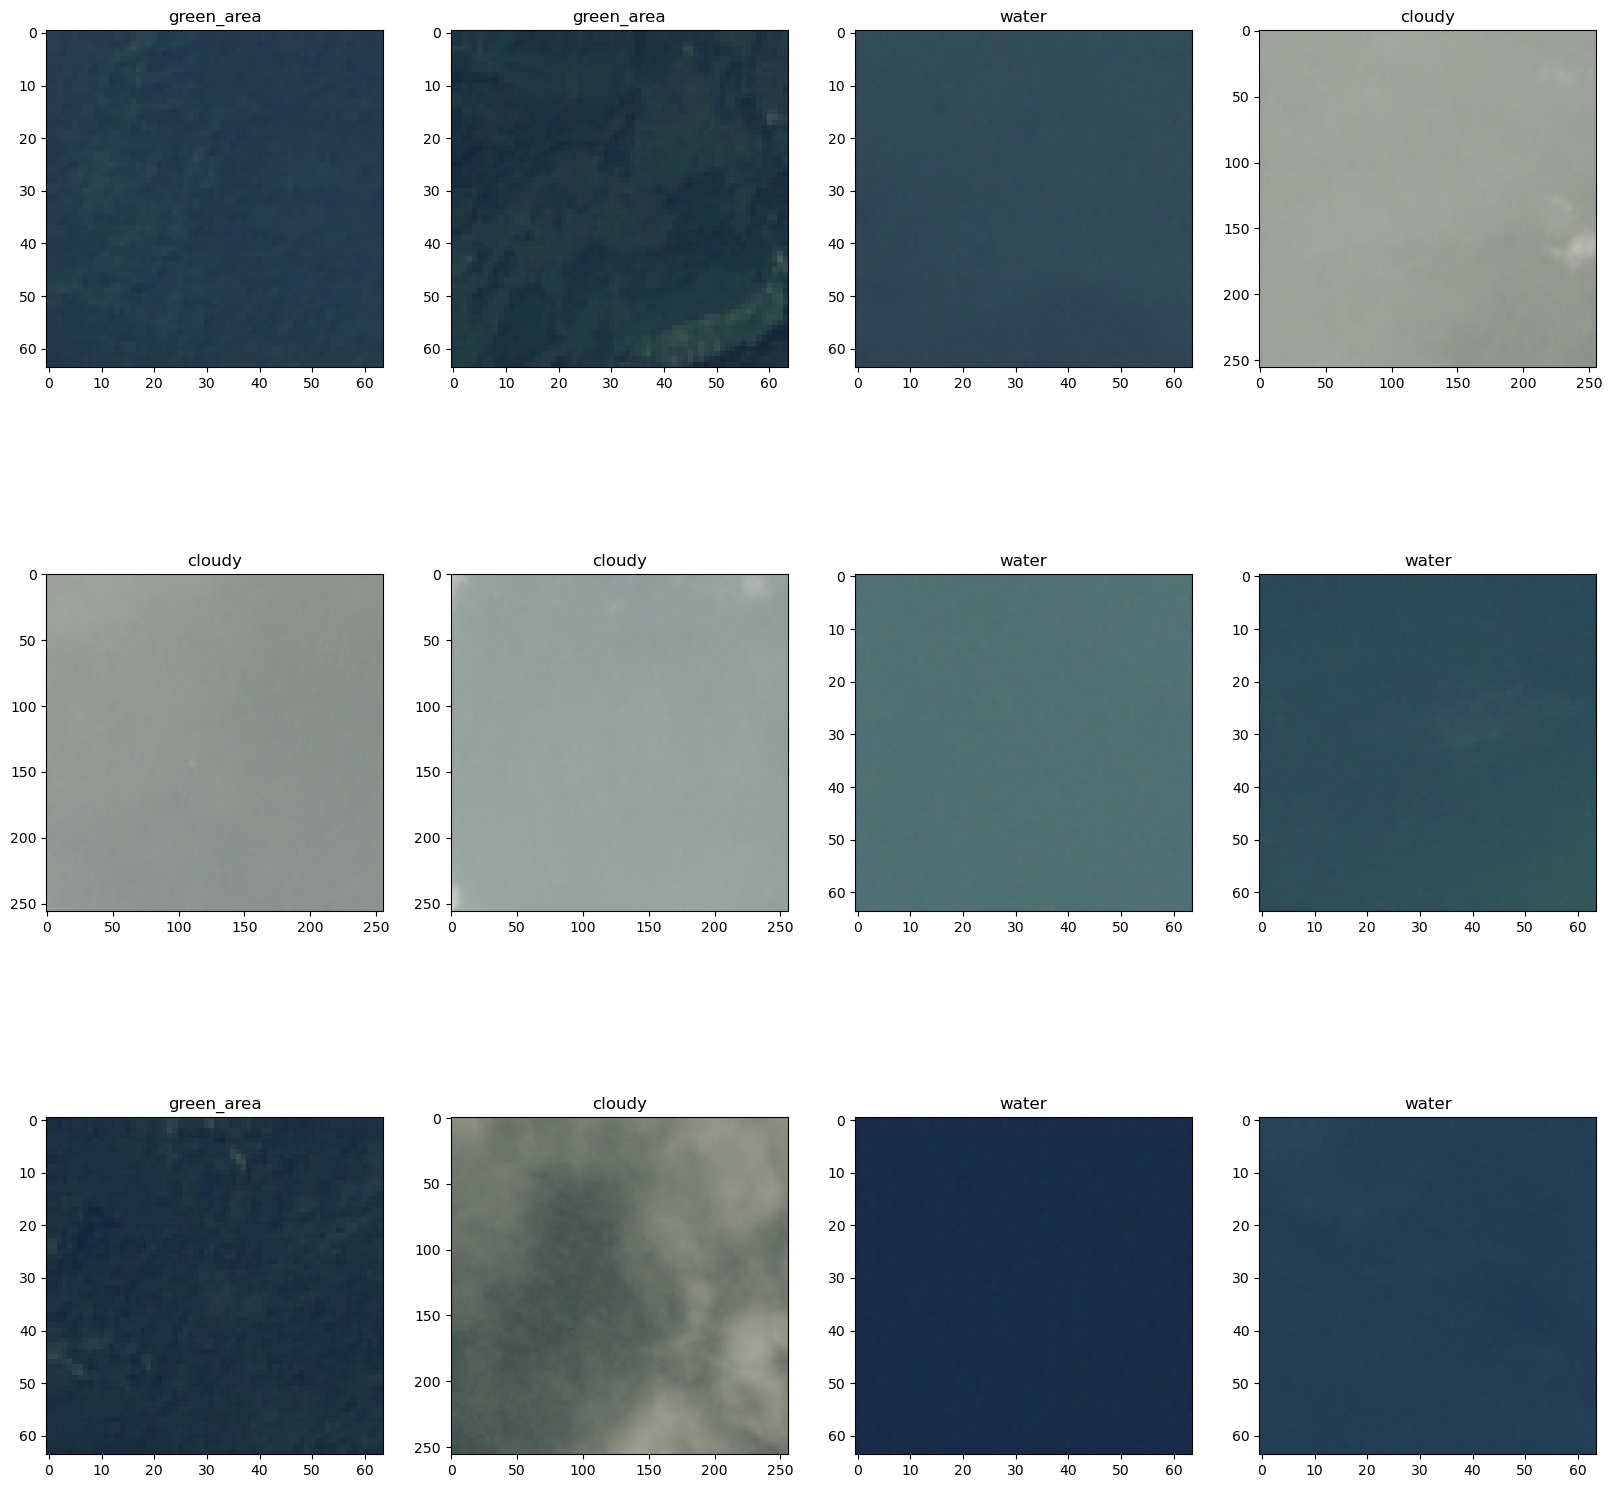

In [6]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    if labels[i] == 0:
        plt.title('cloudy')
    elif labels[i] == 1:
        plt.title('desert')
    elif labels[i] == 2:
        plt.title('green_area')
    else:
        plt.title('water')

In [7]:
images_resized = []

for i in images:
    images_resized.append(resize(i , (64,64,3)))

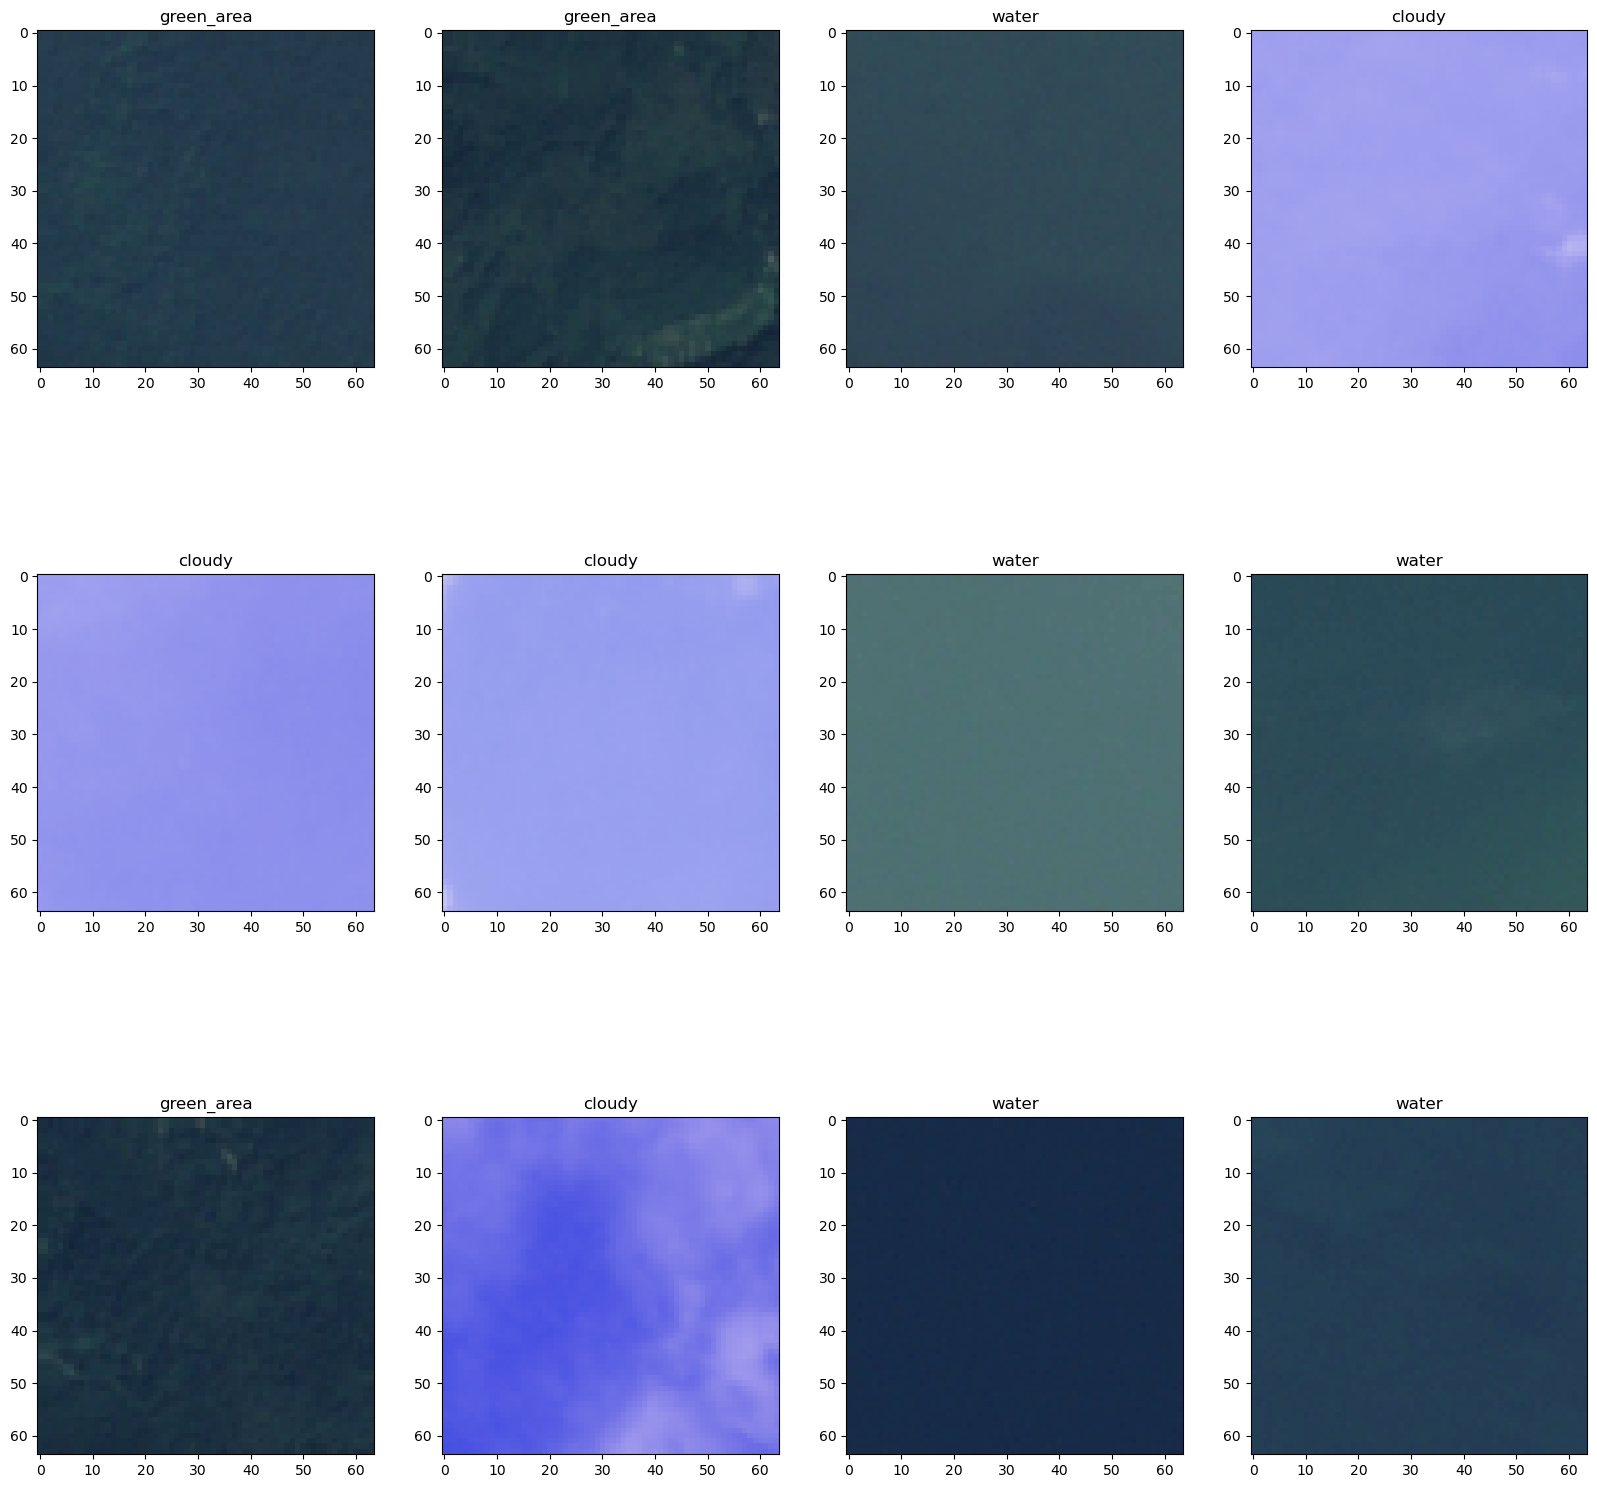

In [8]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images_resized[i])
    if labels[i] == 0:
        plt.title('cloudy')
    elif labels[i] == 1:
        plt.title('desert')
    elif labels[i] == 2:
        plt.title('green_area')
    else:
        plt.title('water')

In [9]:
print(len(images_resized), len(labels))

5631 5631


In [10]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(images_resized , labels , test_size = 0.3 , random_state = 12)

In [11]:
print(type(X_train) , type(y_train))

<class 'list'> <class 'list'>


In [12]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [13]:
print(type(X_train) , type(y_train))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [14]:
print(X_train.shape , y_train.shape)

(3941, 64, 64, 3) (3941,)


In [15]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16 , (3,3) , activation = 'relu' ,input_shape = (64, 64 , 3)),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(32 , (3,3) , activation = 'relu'),
    keras.layers.MaxPooling2D(),

    keras.layers.Flatten(),
    keras.layers.Dense(64 , activation = 'relu'),
    keras.layers.Dense(4 , activation = 'softmax')
])

C:\Users\Asharaf\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,820 (1.55 MB)

 Trainable params: 406,820 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])

In [28]:
model.fit(X_train , y_train , epochs = 10 , validation_split  = 0.2)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9385 - loss: 0.1475 - val_accuracy: 0.9417 - val_loss: 0.1388
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9277 - loss: 0.1588 - val_accuracy: 0.9506 - val_loss: 0.1259
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9429 - loss: 0.1317 - val_accuracy: 0.9468 - val_loss: 0.1356
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9499 - loss: 0.1174 - val_accuracy: 0.9544 - val_loss: 0.1235
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9499 - loss: 0.1204 - val_accuracy: 0.9607 - val_loss: 0.1062
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9480 - loss: 0.1260 - val_accuracy: 0.9506 - val_loss: 0.1218
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9410 - loss: 0.1378 - val_accuracy: 0.9480 - val_loss: 0.1344
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9477 - loss: 0.1233 - val_accuracy: 0.9620 - v

In [29]:
pred = model.predict(X_test)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [30]:
model.evaluate(X_train , y_train)

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9591 - loss: 0.0986 


[0.09863893687725067, 0.9591474533081055]

In [31]:
pred = [np.argmax(i) for i in pred]

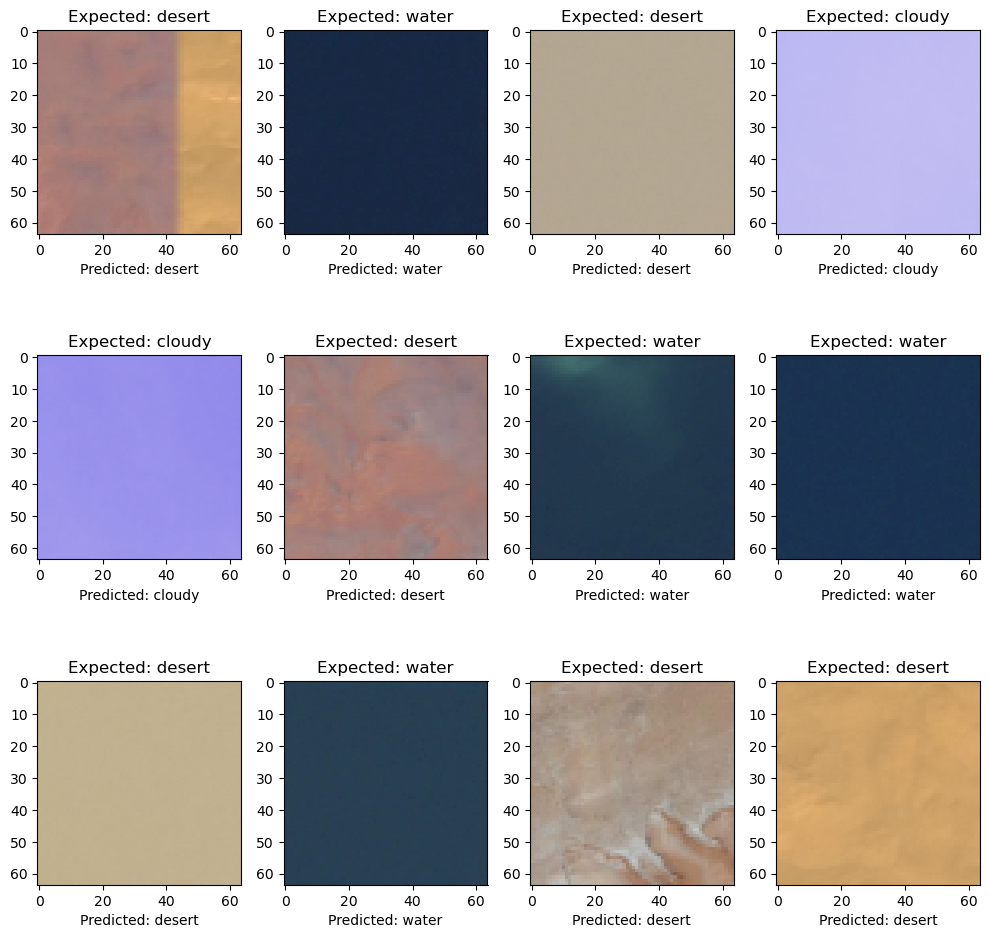

In [33]:
labels = ['cloudy', 'desert', 'green_area', 'water']

plt.figure(figsize=(10,10))
for idx, i in enumerate(range(100, 112)):
    plt.subplot(3,4,idx+1)
    plt.imshow(X_test[i])
    
    plt.title('Expected: ' + labels[y_test[i]])
    plt.xlabel('Predicted: ' + labels[pred[i]])

plt.tight_layout()

# Model Evaluation

<Axes: >

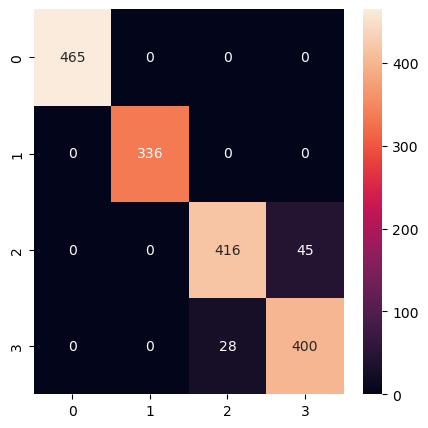

In [34]:
plt.figure(figsize = (5,5))
sns.heatmap(confusion_matrix(y_test , pred) , annot = True , fmt = 'd')

### Accuracy score

In [35]:
accuracy_score(y_test ,pred)

0.9568047337278106

### Classification report

In [36]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       465
           1       1.00      1.00      1.00       336
           2       0.94      0.90      0.92       461
           3       0.90      0.93      0.92       428

    accuracy                           0.96      1690
   macro avg       0.96      0.96      0.96      1690
weighted avg       0.96      0.96      0.96      1690



***